===== CONSTANT RESISTIVITY FIT =====
rho_Pt   = 3.173e-07 Ohm m = 31.7 uOhm cm
rho_CFB  = 1.982e-06 Ohm m = 198.2 uOhm cm

===== THICKNESS DEPENDENT Pt FIT =====
rho0_Pt   = 1.250e-07 Ohm m = 12.5 uOhm cm
lambda_Pt = 12.82 nm
rho_CFB   = 6.810e-07 Ohm m = 68.1 uOhm cm


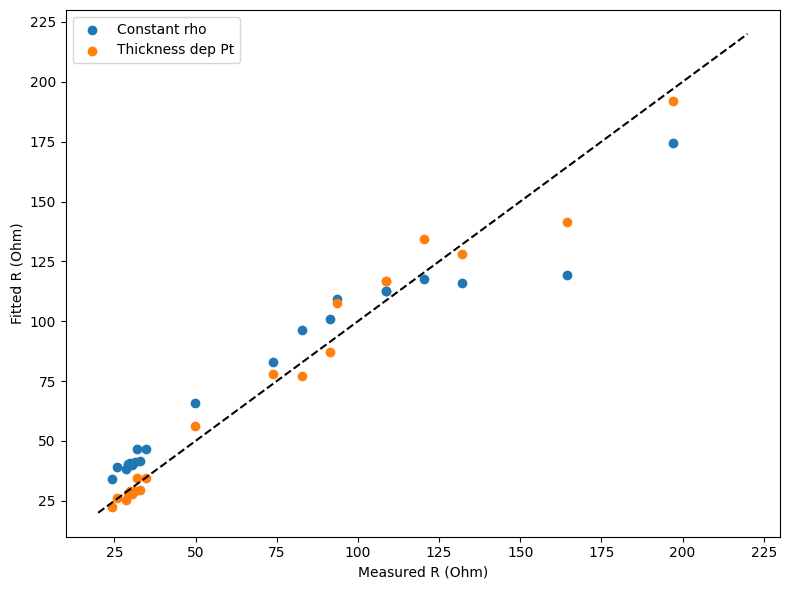

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1) Store samples as a list, not a dict, to avoid duplicate-key overwrites
# -----------------------------------------------------------------------------

samples = [
    {"sample": "SSN138", "t_FM": 4e-9,  "t_NM": 3e-9,  "label": "CFB4", "R": 197.0},
    {"sample": "SSN101", "t_FM": 4e-9,  "t_NM": 5e-9,  "label": "CFB4", "R": 108.8},
    {"sample": "SSN139", "t_FM": 4e-9,  "t_NM": 7e-9,  "label": "CFB4", "R": 74.0},
    {"sample": "SSN140", "t_FM": 4e-9,  "t_NM": 18e-9, "label": "CFB4", "R": 24.4},
    {"sample": "SSN141", "t_FM": 4e-9,  "t_NM": 9e-9,  "label": "CFB4", "R": 49.8},
    {"sample": "SSN142", "t_FM": 4e-9,  "t_NM": 13e-9, "label": "CFB4", "R": 31.9},
    {"sample": "SSN095", "t_FM": 4e-9,  "t_NM": 15e-9, "label": "CFB4", "R": 30.5},
    {"sample": "SSN143", "t_FM": 4e-9,  "t_NM": 13e-9, "label": "CFB4", "R": 34.8},

    {"sample": "SSN092", "t_FM": 2e-9,   "t_NM": 15e-9, "label": "15nm", "R": 32.8},
    {"sample": "SSN093", "t_FM": 2.5e-9, "t_NM": 15e-9, "label": "15nm", "R": 31.4},
    {"sample": "SSN094", "t_FM": 3e-9,   "t_NM": 15e-9, "label": "15nm", "R": 29.7},
    {"sample": "SSN095", "t_FM": 4e-9,   "t_NM": 15e-9, "label": "15nm", "R": 29.3},
    {"sample": "DK159",  "t_FM": 5e-9,   "t_NM": 15e-9, "label": "15nm", "R": 30.3},
    {"sample": "SSN096", "t_FM": 8e-9,   "t_NM": 15e-9, "label": "15nm", "R": 25.7},
    {"sample": "SSN097", "t_FM": 10e-9,  "t_NM": 15e-9, "label": "15nm", "R": 28.5},

    {"sample": "SSN098", "t_FM": 2e-9,   "t_NM": 5e-9, "label": "5nm", "R": 164.4},
    {"sample": "SSN099", "t_FM": 2.5e-9, "t_NM": 5e-9, "label": "5nm", "R": 120.5},
    {"sample": "SSN100", "t_FM": 3e-9,   "t_NM": 5e-9, "label": "5nm", "R": 132.0},
    {"sample": "SSN101", "t_FM": 4e-9,   "t_NM": 5e-9, "label": "5nm", "R": 108.8},
    {"sample": "DK158",  "t_FM": 5e-9,   "t_NM": 5e-9, "label": "5nm", "R": 93.6},
    {"sample": "SSN102", "t_FM": 8e-9,   "t_NM": 5e-9, "label": "5nm", "R": 91.3},
    {"sample": "SSN103", "t_FM": 10e-9,  "t_NM": 5e-9, "label": "5nm", "R": 82.9},
]

# ==========================================================
# DEVICE GEOMETRY
# ==========================================================
W = 20e-6   # width (m)
L = 40e-6   # length (m)

# ==========================================================
# PREPARE DATA
# ==========================================================
t_FM = np.array([s["t_FM"] for s in samples])
t_NM = np.array([s["t_NM"] for s in samples])
R_meas = np.array([s["R"] for s in samples])

# ==========================================================
# MODEL 1: CONSTANT RESISTIVITY
# ==========================================================
def model_constant(X, rho_pt, rho_cfb):
    t_FM, t_NM = X

    G = (W/L) * (t_NM/rho_pt + t_FM/rho_cfb)
    return 1/G

p0 = [3e-7, 1.5e-6]

popt, pcov = curve_fit(model_constant, (t_FM, t_NM), R_meas, p0=p0)

rho_pt, rho_cfb = popt

print("===== CONSTANT RESISTIVITY FIT =====")
print(f"rho_Pt   = {rho_pt:.3e} Ohm m = {rho_pt*1e8:.1f} uOhm cm")
print(f"rho_CFB  = {rho_cfb:.3e} Ohm m = {rho_cfb*1e8:.1f} uOhm cm")

R_fit = model_constant((t_FM, t_NM), *popt)

# ==========================================================
# MODEL 2: THICKNESS DEPENDENT Pt
# rho(t)=rho0*(1+lambda/t)
# ==========================================================
def model_thickness(X, rho0_pt, lamb_pt, rho_cfb):
    t_FM, t_NM = X

    rho_pt_eff = rho0_pt * (1 + lamb_pt/t_NM)

    G = (W/L) * (t_NM/rho_pt_eff + t_FM/rho_cfb)

    return 1/G

p0 = [2e-7, 2e-9, 1.5e-6]

popt2, pcov2 = curve_fit(model_thickness, (t_FM, t_NM), R_meas, p0=p0)

rho0_pt, lamb_pt, rho_cfb2 = popt2

print("\n===== THICKNESS DEPENDENT Pt FIT =====")
print(f"rho0_Pt   = {rho0_pt:.3e} Ohm m = {rho0_pt*1e8:.1f} uOhm cm")
print(f"lambda_Pt = {lamb_pt*1e9:.2f} nm")
print(f"rho_CFB   = {rho_cfb2:.3e} Ohm m = {rho_cfb2*1e8:.1f} uOhm cm")

R_fit2 = model_thickness((t_FM, t_NM), *popt2)

# ==========================================================
# PLOT
# ==========================================================
plt.figure(figsize=(8,6))
plt.scatter(R_meas, R_fit, label="Constant rho")
plt.scatter(R_meas, R_fit2, label="Thickness dep Pt")
plt.plot([20,220],[20,220],'k--')
plt.xlabel("Measured R (Ohm)")
plt.ylabel("Fitted R (Ohm)")
plt.legend()
plt.tight_layout()
plt.show()


========= GLOBAL FIT RESULTS =========
Pt bulk resistivity:
rho0_Pt = 1.708e-07 ± 1.238e-07 Ohm m
        = 17.08 ± 12.38 µΩ·cm

Pt scattering length:
lambda_Pt = 5.30 ± 9.19 nm

CoFeB bulk resistivity:
rho0_CFB = 1.264e-06 ± 3.350e-06 Ohm m
         = 126.40 ± 335.04 µΩ·cm

CoFeB scattering length:
lambda_CFB = 0.13 ± 39.07 nm

RMSE = 10.86 Ohm


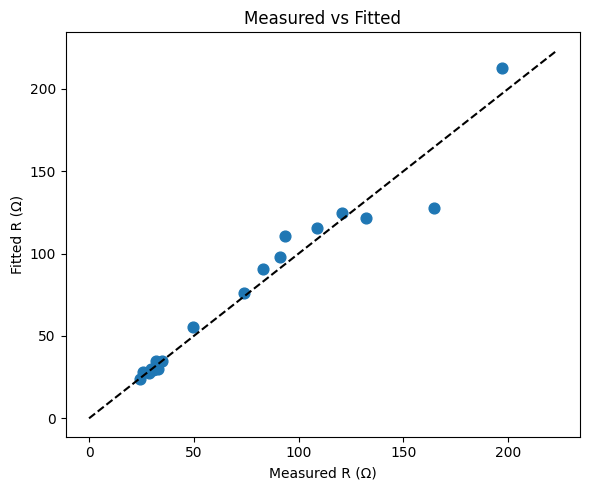

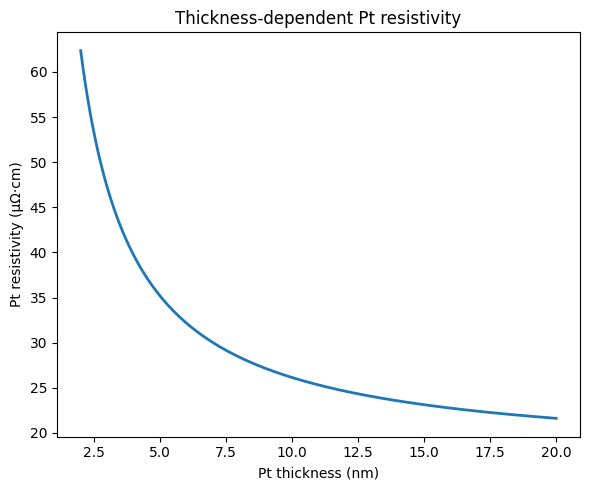

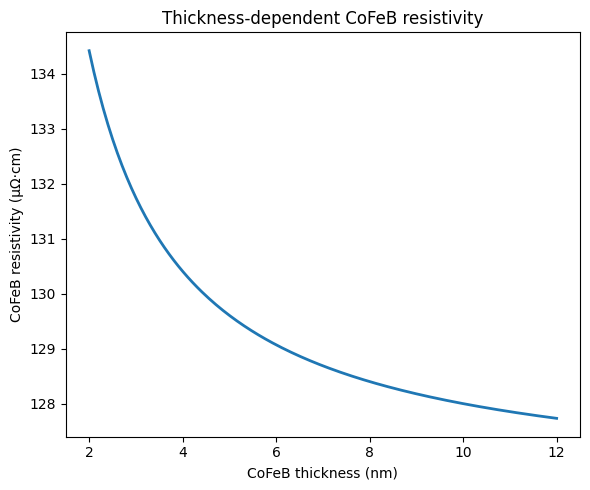


Sample-by-sample comparison:
SSN138    Meas= 197.00 Ω   Fit= 212.44 Ω
SSN101    Meas= 108.80 Ω   Fit= 115.78 Ω
SSN139    Meas=  74.00 Ω   Fit=  75.80 Ω
SSN140    Meas=  24.40 Ω   Fit=  23.68 Ω
SSN141    Meas=  49.80 Ω   Fit=  55.21 Ω
SSN142    Meas=  31.90 Ω   Fit=  35.01 Ω
SSN095    Meas=  30.50 Ω   Fit=  29.43 Ω
SSN143    Meas=  34.80 Ω   Fit=  35.01 Ω
SSN092    Meas=  32.80 Ω   Fit=  30.14 Ω
SSN093    Meas=  31.40 Ω   Fit=  29.96 Ω
SSN094    Meas=  29.70 Ω   Fit=  29.78 Ω
SSN096    Meas=  25.70 Ω   Fit=  28.13 Ω
SSN097    Meas=  28.50 Ω   Fit=  27.51 Ω
SSN098    Meas= 164.40 Ω   Fit= 127.43 Ω
SSN099    Meas= 120.50 Ω   Fit= 124.30 Ω
SSN100    Meas= 132.00 Ω   Fit= 121.32 Ω
DK158     Meas=  93.60 Ω   Fit= 110.71 Ω
SSN102    Meas=  91.30 Ω   Fit=  97.86 Ω
SSN103    Meas=  82.90 Ω   Fit=  90.83 Ω


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t

# ==========================================================
# FULL DATASET
# ==========================================================
samples = [
    {"sample": "SSN138", "t_FM": 4e-9,  "t_NM": 3e-9,  "R": 197.0},
    {"sample": "SSN101", "t_FM": 4e-9,  "t_NM": 5e-9,  "R": 108.8},
    {"sample": "SSN139", "t_FM": 4e-9,  "t_NM": 7e-9,  "R": 74.0},
    {"sample": "SSN140", "t_FM": 4e-9,  "t_NM": 18e-9, "R": 24.4},
    {"sample": "SSN141", "t_FM": 4e-9,  "t_NM": 9e-9,  "R": 49.8},
    {"sample": "SSN142", "t_FM": 4e-9,  "t_NM": 13e-9, "R": 31.9},
    {"sample": "SSN095", "t_FM": 4e-9,  "t_NM": 15e-9, "R": 30.5},
    {"sample": "SSN143", "t_FM": 4e-9,  "t_NM": 13e-9, "R": 34.8},

    {"sample": "SSN092", "t_FM": 2e-9,   "t_NM": 15e-9, "R": 32.8},
    {"sample": "SSN093", "t_FM": 2.5e-9, "t_NM": 15e-9, "R": 31.4},
    {"sample": "SSN094", "t_FM": 3e-9,   "t_NM": 15e-9, "R": 29.7},
    {"sample": "SSN096", "t_FM": 8e-9,   "t_NM": 15e-9, "R": 25.7},
    {"sample": "SSN097", "t_FM": 10e-9,  "t_NM": 15e-9, "R": 28.5},

    {"sample": "SSN098", "t_FM": 2e-9,   "t_NM": 5e-9, "R": 164.4},
    {"sample": "SSN099", "t_FM": 2.5e-9, "t_NM": 5e-9, "R": 120.5},
    {"sample": "SSN100", "t_FM": 3e-9,   "t_NM": 5e-9, "R": 132.0},
    {"sample": "DK158",  "t_FM": 5e-9,   "t_NM": 5e-9, "R": 93.6},
    {"sample": "SSN102", "t_FM": 8e-9,   "t_NM": 5e-9, "R": 91.3},
    {"sample": "SSN103", "t_FM": 10e-9,  "t_NM": 5e-9, "R": 82.9},
]

# ==========================================================
# DEVICE GEOMETRY
# ==========================================================
W = 20e-6   # width (m)
L = 40e-6   # length (m)

# ==========================================================
# ARRAYS
# ==========================================================
t_FM = np.array([s["t_FM"] for s in samples])   # CoFeB thickness
t_NM = np.array([s["t_NM"] for s in samples])   # Pt thickness
R_meas = np.array([s["R"] for s in samples])

# ==========================================================
# GLOBAL THICKNESS-DEPENDENT MODEL
# rho(t)=rho0*(1+lambda/t)
# ==========================================================
def rho_model(t, rho0, lamb):
    return rho0 * (1.0 + lamb / t)

def bilayer_model(X, rho0_pt, lamb_pt, rho0_cfb, lamb_cfb):
    t_FM, t_NM = X

    rho_pt  = rho_model(t_NM, rho0_pt, lamb_pt)
    rho_cfb = rho_model(t_FM, rho0_cfb, lamb_cfb)

    G = (W / L) * (t_NM / rho_pt + t_FM / rho_cfb)

    return 1.0 / G

# ==========================================================
# INITIAL GUESSES
# ==========================================================
p0 = [
    2.0e-7,   # rho0 Pt
    2.0e-9,   # lambda Pt
    1.5e-6,   # rho0 CoFeB
    1.0e-9    # lambda CoFeB
]

# Positive bounds only
lower = [1e-9, 0, 1e-9, 0]
upper = [1e-4, 100e-9, 1e-3, 100e-9]

# ==========================================================
# FIT
# ==========================================================
popt, pcov = curve_fit(
    bilayer_model,
    (t_FM, t_NM),
    R_meas,
    p0=p0,
    bounds=(lower, upper),
    maxfev=20000
)

rho0_pt, lamb_pt, rho0_cfb, lamb_cfb = popt

# ==========================================================
# CONFIDENCE INTERVALS
# ==========================================================
n = len(R_meas)
p = len(popt)
dof = max(0, n - p)

alpha = 0.05
tval = t.ppf(1.0 - alpha/2., dof)

perr = np.sqrt(np.diag(pcov))
ci = perr * tval

# ==========================================================
# PRINT RESULTS
# ==========================================================
print("\n========= GLOBAL FIT RESULTS =========")

print(f"Pt bulk resistivity:")
print(f"rho0_Pt = {rho0_pt:.3e} ± {ci[0]:.3e} Ohm m")
print(f"        = {rho0_pt*1e8:.2f} ± {ci[0]*1e8:.2f} µΩ·cm")

print(f"\nPt scattering length:")
print(f"lambda_Pt = {lamb_pt*1e9:.2f} ± {ci[1]*1e9:.2f} nm")

print(f"\nCoFeB bulk resistivity:")
print(f"rho0_CFB = {rho0_cfb:.3e} ± {ci[2]:.3e} Ohm m")
print(f"         = {rho0_cfb*1e8:.2f} ± {ci[2]*1e8:.2f} µΩ·cm")

print(f"\nCoFeB scattering length:")
print(f"lambda_CFB = {lamb_cfb*1e9:.2f} ± {ci[3]*1e9:.2f} nm")

# ==========================================================
# FITTED RESISTANCES
# ==========================================================
R_fit = bilayer_model((t_FM, t_NM), *popt)

rmse = np.sqrt(np.mean((R_meas - R_fit)**2))
print(f"\nRMSE = {rmse:.2f} Ohm")

# ==========================================================
# EXTRACT THICKNESS-DEPENDENT RESISTIVITIES
# ==========================================================
t_pt_range = np.linspace(2, 20, 200) * 1e-9
rho_pt_curve = rho_model(t_pt_range, rho0_pt, lamb_pt)

t_cfb_range = np.linspace(2, 12, 200) * 1e-9
rho_cfb_curve = rho_model(t_cfb_range, rho0_cfb, lamb_cfb)

# ==========================================================
# PLOTS
# ==========================================================
plt.figure(figsize=(6,5))
plt.scatter(R_meas, R_fit, s=60)
mx = max(R_meas.max(), R_fit.max())*1.05
plt.plot([0,mx],[0,mx],'k--')
plt.xlabel("Measured R (Ω)")
plt.ylabel("Fitted R (Ω)")
plt.title("Measured vs Fitted")
plt.tight_layout()

plt.figure(figsize=(6,5))
plt.plot(t_pt_range*1e9, rho_pt_curve*1e8, lw=2)
plt.xlabel("Pt thickness (nm)")
plt.ylabel("Pt resistivity (µΩ·cm)")
plt.title("Thickness-dependent Pt resistivity")
plt.tight_layout()

plt.figure(figsize=(6,5))
plt.plot(t_cfb_range*1e9, rho_cfb_curve*1e8, lw=2)
plt.xlabel("CoFeB thickness (nm)")
plt.ylabel("CoFeB resistivity (µΩ·cm)")
plt.title("Thickness-dependent CoFeB resistivity")
plt.tight_layout()

plt.show()

# ==========================================================
# OPTIONAL: PRINT SAMPLE-BY-SAMPLE TABLE
# ==========================================================
print("\nSample-by-sample comparison:")
for s, rm, rf in zip(samples, R_meas, R_fit):
    print(f"{s['sample']:8s}  Meas={rm:7.2f} Ω   Fit={rf:7.2f} Ω")

| Sample | Pt thickness (nm) | Pt resistivity (µΩ·cm) | CoFeB resistivity (µΩ·cm) |
| ------ | ----------------: | ---------------------: | ------------------------: |
| SSN138 |                 3 |                     63 |                       170 |
| SSN101 |                 5 |                     45 |                       170 |
| SSN139 |                 7 |                     37 |                       170 |
| SSN141 |                 9 |                     33 |                       170 |
| SSN142 |                13 |                     29 |                       170 |
| SSN143 |                13 |                     29 |                       170 |
| SSN095 |                15 |                     28 |                       170 |
| SSN140 |                18 |                     27 |                       170 |
